# Distribution Explorer for Manual Threshold Setting

Purpose: provide a deep view of each rule's distribution so the researcher
can read the data and set thresholds manually rather than via quantile
calibration.

## Why this notebook exists

The previous calibration approach (Threshold Calibration v1, v2) used
percentile-based methods (p75, p90, bimodal valley) to derive thresholds.
The fundamental issue: percentile methods assume you know what fraction of
data is "bad" in advance. They flag the worst N% by definition, regardless
of whether those N% are actually bad.

For setting **quality standards** — the question "where is the cliff
between acceptable and unacceptable on this metric?" — manual inspection
of the distribution is more appropriate than automated calibration. This
notebook provides the data and visualizations needed to make that decision
informed by evidence rather than guessed.

## What this notebook does NOT do

- No automatic threshold derivation
- No bimodal valley algorithm output as a decision driver
- No reference-dict accommodation logic
- No "high/medium/low confidence" tagging
- No connection to existing tier classifications (those depend on the
  threshold you're about to set, so referring to them would be circular)

Distribution shape diagnostics (dip p-value, skewness) are still reported
as **information**, not as decision drivers. They help you see whether the
distribution is unimodal, bimodal, or skewed — but you decide the threshold.

## Rules in scope (10 total)

1. `morph_low_tag_coverage`
2. `morph_too_few_rows`
3. `billex_high_multiword_ind`
4. `billex_too_few_rows`
5. `billex_high_null_rate`
6. `billex_low_retention`
7. `parcor_high_placeholders`
8. `parcor_too_few_rows`
9. `parcor_high_null_rate`
10. `parcor_high_short_rows`

Each rule gets a self-contained section with: distribution diagnostics,
histogram with what-if threshold lines, per-dict ranked table, and a
candidate-threshold table.

## Output files (in `../evaluation/distribution_exploration/`)

- `_per_rule_distributions.csv` — every dict's metric value for every rule
- `_my_thresholds.csv` — empty template for you to fill in your decisions
- One CSV per rule with the per-dict values and rank: `_<rule_name>.csv`

These are decision-support artifacts, not deliverables. Once you've used
them to make threshold decisions, you'll write the chosen thresholds into
`_my_thresholds.csv` and feed them into the next iteration of sanity
checks.

## 1. Configuration & loading

In [27]:
import re
import ast
from pathlib import Path
from typing import Optional

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import diptest

from _common import parse_dict_id, load_direction_lookup, direction_for

DIRS = {
    "prep":   Path("../Ekstraksi/6. Pemecahan Definisi Lema"),
    "billex": Path("../Ekstraksi/9. Bilingual Lexicon"),
    "morph":  Path("../Ekstraksi/10. Morphology"),
    "parcor": Path("../Ekstraksi/11. Parallel Corpus"),
}
DST_DIR = Path("../csvAnalysis/distribution_exploration")
DST_DIR.mkdir(parents=True, exist_ok=True)
RETENTION_MIN_PREP_ROWS = 100  # below this, retention is undefined

print(f"Output dir: {DST_DIR.resolve()}")

Output dir: C:\Users\Legion\OneDrive\Documents\UNI\TA\tugas-akhir-data-mining\TAEkstraksiKamus\csvAnalysis\distribution_exploration


## 2. Load per-dict metrics

In [28]:
def parse_list_cell(s):
    if isinstance(s, list): return s
    try:
        v = ast.literal_eval(s) if isinstance(s, str) else []
        return v if isinstance(v, list) else []
    except Exception:
        return []


def collect_billex_metrics(path: Path, direction: Optional[int]) -> dict:
    df = pd.read_csv(path)
    n = len(df)
    if n == 0 or "kata_asal" not in df.columns or "kata_tujuan" not in df.columns:
        return {"billex_rows": n}
    if direction == 1:
        ind_col, reg_col = "kata_asal", "kata_tujuan"
    else:
        ind_col, reg_col = "kata_tujuan", "kata_asal"

    def first_of(v):
        if not isinstance(v, str): return ""
        lst = parse_list_cell(v)
        if lst:
            first = lst[0]
            return str(first).strip() if first is not None else ""
        return v.strip()

    if direction == 1:
        ind_series = df[ind_col].fillna("").astype(str).str.strip()
    else:
        ind_series = df[ind_col].apply(first_of)

    null_rate = df[[ind_col, reg_col]].isna().any(axis=1).mean()
    multiword_ind_rate = ind_series.str.contains(r"\s", na=False, regex=True).mean()
    return {
        "billex_rows": n,
        "billex_null_rate": round(float(null_rate), 4),
        "billex_multiword_ind_rate": round(float(multiword_ind_rate), 4),
    }


def collect_morph_metrics(path: Path) -> dict:
    df = pd.read_csv(path)
    n = len(df)
    if n == 0:
        return {"morph_rows": 0}
    if "tag" in df.columns:
        tag_col = df["tag"].fillna("").astype(str).str.strip()
        rate = ((tag_col != "") & (tag_col.str.lower() != "nan")).mean()
    else:
        rate = 0.0
    return {"morph_rows": n, "morph_tag_coverage": round(float(rate), 4)}


def collect_parcor_metrics(path: Path) -> dict:
    df = pd.read_csv(path)
    n = len(df)
    if n == 0:
        return {"parcor_rows": 0}
    if "kalimat_asal" not in df.columns or "kalimat_tujuan" not in df.columns:
        return {"parcor_rows": n, "parcor_null_rate": 1.0}
    asal = df["kalimat_asal"].fillna("").astype(str)
    tujuan = df["kalimat_tujuan"].fillna("").astype(str)
    null_rate = df[["kalimat_asal", "kalimat_tujuan"]].isna().any(axis=1).mean()
    placeholder_re = re.compile(r"(?:^|\s)(--|-)(?=\s|$|[.,;:!?])")
    ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()
    len_asal = asal.apply(lambda s: len(s.split()) if isinstance(s, str) else 0)
    len_tujuan = tujuan.apply(lambda s: len(s.split()) if isinstance(s, str) else 0)
    short_rate = ((len_asal <= 2) | (len_tujuan <= 2)).mean()
    return {
        "parcor_rows": n,
        "parcor_null_rate": round(float(null_rate), 4),
        "parcor_placeholder_rate": round(float(ph_rate), 4),
        "parcor_short_rate": round(float(short_rate), 4),
    }


def get_prep_rows(dict_id: str) -> int:
    if not DIRS["prep"].exists(): return 0
    files = list(DIRS["prep"].glob(f"{dict_id}_*.csv"))
    if not files: return 0
    try: return len(pd.read_csv(files[0]))
    except Exception: return 0


def find_csv(dir_: Path, dict_id: str, suffix: str) -> Optional[Path]:
    if not dir_.exists(): return None
    matches = list(dir_.glob(f"{dict_id}_{suffix}.csv"))
    return matches[0] if matches else None


billex_files = sorted(DIRS["billex"].glob("*_Billex.csv")) if DIRS["billex"].exists() else []
dict_ids = sorted({parse_dict_id(p.name) for p in billex_files} - {None}, key=lambda s: int(s))
direction_lookup = load_direction_lookup()

rows = []
for dict_id in dict_ids:
    m = {"dict_id": dict_id, "direction": direction_for(dict_id, direction_lookup)}
    m["prep_rows"] = get_prep_rows(dict_id)

    p_b = find_csv(DIRS["billex"], dict_id, "Billex")
    if p_b: m.update(collect_billex_metrics(p_b, m["direction"] or 1))

    p_m = find_csv(DIRS["morph"], dict_id, "Morphology")
    if p_m: m.update(collect_morph_metrics(p_m))

    p_p = find_csv(DIRS["parcor"], dict_id, "Parcor")
    if p_p: m.update(collect_parcor_metrics(p_p))

    # Billex retention only (per scope decision)
    if m["prep_rows"] >= RETENTION_MIN_PREP_ROWS and "billex_rows" in m:
        m["billex_retention"] = round(m["billex_rows"] / m["prep_rows"], 4)
    else:
        m["billex_retention"] = np.nan

    rows.append(m)

metrics_df = pd.DataFrame(rows).sort_values("dict_id", key=lambda s: s.astype(int)).reset_index(drop=True)
print(f"Loaded {len(metrics_df)} dictionaries")
print(f"\nAvailable columns: {[c for c in metrics_df.columns if c not in ['dict_id', 'direction']]}")

C:\Users\Legion\AppData\Local\Temp\ipykernel_29100\1679125208.py:66: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()
C:\Users\Legion\AppData\Local\Temp\ipykernel_29100\1679125208.py:66: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()
C:\Users\Legion\AppData\Local\Temp\ipykernel_29100\1679125208.py:66: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()
C:\Users\Legion\AppData\Local\Temp\ipykernel_29100\1679125208.py:66: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually 

Loaded 68 dictionaries

Available columns: ['prep_rows', 'billex_rows', 'billex_null_rate', 'billex_multiword_ind_rate', 'morph_rows', 'morph_tag_coverage', 'parcor_rows', 'parcor_null_rate', 'parcor_placeholder_rate', 'parcor_short_rate', 'billex_retention']


C:\Users\Legion\AppData\Local\Temp\ipykernel_29100\1679125208.py:66: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()


## 3. Helper: `explore_rule`

Single function that produces, for one rule:
- Distribution diagnostics (5-number summary, dip p, skewness)
- Histogram with candidate-threshold lines
- Sorted per-dict table (worst first)
- What-if threshold table (quantile grid + distribution landmarks)
- Per-rule CSV output

In [29]:
def explore_rule(rule_name: str, metric_col: str, direction: str):
    """
    Per-rule deep exploration. Prints diagnostics, draws histogram,
    saves per-dict CSV. No threshold decision is made here.
    """
    if metric_col not in metrics_df.columns:
        print(f"⚠ Column {metric_col} not in metrics_df. Skipping.")
        return

    # Pull values, dropping NaN for stats but keeping in per-dict list as 'n/a'
    # Build column list, deduplicating to handle metric_col == one of the context columns
    base_cols = ["dict_id", "prep_rows", "billex_rows", "morph_rows", "parcor_rows"]
    cols_needed = base_cols + ([metric_col] if metric_col not in base_cols else [])
    sub = metrics_df[cols_needed].copy()
    valid = sub.dropna(subset=[metric_col]).copy()
    values = valid[metric_col].values.astype(float)

    if len(values) < 5:
        print(f"⚠ Insufficient data for {rule_name}: only {len(values)} valid values")
        return

    # === SECTION A: Distribution diagnostics ===
    n_total = len(metrics_df)
    n_valid = len(values)
    n_na = n_total - n_valid

    p1, p5, p10, p25, p50, p75, p90, p95, p99 = np.percentile(
        values, [1, 5, 10, 25, 50, 75, 90, 95, 99]
    )
    mean = float(np.mean(values))
    std  = float(np.std(values))
    # Force 1-D array — guards against accidentally 2-D inputs from unusual columns
    values = np.asarray(values).ravel().astype(float)
    values = values[~np.isnan(values)]

    if std > 1e-9 and len(values) >= 3:
        # Try multiple skewness implementations, falling back as needed
        try:
            skewness = float(pd.Series(values).skew())  # pandas: most robust
            if np.isnan(skewness):
                skewness = 0.0
        except Exception:
            try:
                raw = np.asarray(stats.skew(values, bias=True)).flatten()
                skewness = float(raw[0]) if len(raw) > 0 else 0.0
                if np.isnan(skewness):
                    skewness = 0.0
            except Exception:
                skewness = 0.0
    else:
        skewness = 0.0
    try:
        dip_stat, dip_pval = diptest.diptest(values)
    except Exception:
        dip_stat, dip_pval = float("nan"), float("nan")

    print(f"=== {rule_name} ===\n")
    print(f"Metric: {metric_col}    Direction: {direction} ({'low=bad' if direction=='low' else 'high=bad'})")
    print(f"Coverage: {n_valid} valid values, {n_na} N/A "
          f"({n_na/n_total:.1%} missing)\n")

    print(f"Summary statistics:")
    print(f"  min: {values.min():.4f}    max: {values.max():.4f}")
    print(f"  mean: {mean:.4f}    median: {p50:.4f}    std: {std:.4f}")
    print(f"  skewness: {skewness:+.3f}    dip-test p-value: {dip_pval:.4f}")
    print(f"  shape hint: ", end="")
    if dip_pval < 0.05:
        print("BIMODAL (clear separation between two populations)")
    elif abs(skewness) > 1.5:
        print(f"STRONGLY SKEWED ({'right' if skewness > 0 else 'left'} tail)")
    elif abs(skewness) > 0.5:
        print(f"MILDLY SKEWED ({'right' if skewness > 0 else 'left'} tail)")
    else:
        print("APPROXIMATELY SYMMETRIC")

    print(f"\nPercentiles:")
    print(f"  p1={p1:.4f}  p5={p5:.4f}  p10={p10:.4f}  p25={p25:.4f}")
    print(f"  p50={p50:.4f}  p75={p75:.4f}  p90={p90:.4f}  p95={p95:.4f}  p99={p99:.4f}")

    # === SECTION B: Candidate threshold table ===
    # Combine quantile grid (A) and distribution landmarks (B)
    landmarks = []
    quantiles = [
        ("p5",  p5), ("p10", p10), ("p25", p25), ("p50", p50),
        ("p75", p75), ("p90", p90), ("p95", p95),
    ]
    landmarks_extra = [
        ("mean",       mean),
        ("mean − 1σ",  mean - std),
        ("mean − 2σ",  mean - 2 * std),
        ("mean + 1σ",  mean + std),
        ("mean + 2σ",  mean + 2 * std),
    ]

    candidates = quantiles + landmarks_extra

    print(f"\nWhat-if threshold table:")
    print(f"  threshold | flag count | flag rate | type")
    print(f"  ---------|-----------|-----------|-----------")
    for label, candidate in candidates:
        if direction == "low":
            n_flagged = int((values < candidate).sum())
        else:
            n_flagged = int((values > candidate).sum())
        flag_rate = n_flagged / n_valid
        kind = "quantile" if label.startswith("p") else "landmark"
        print(f"  {label:<10} | {candidate:>9.4f} | {n_flagged:>6} ({flag_rate:>5.1%}) | {kind}")

    # === SECTION C: Histogram with candidate threshold lines ===
    fig, ax = plt.subplots(figsize=(11, 5))

    n_bins = min(30, max(10, int(np.sqrt(n_valid))))
    ax.hist(values, bins=n_bins, color="#90a4ae", edgecolor="white", alpha=0.85)

    # Draw quantile lines
    quantile_colors = {"p25": "#1976d2", "p50": "#388e3c", "p75": "#1976d2"}
    for label, candidate in [("p25", p25), ("p50", p50), ("p75", p75)]:
        ax.axvline(candidate, color=quantile_colors[label], linestyle=":",
                   linewidth=1.2, alpha=0.6, label=f"{label}={candidate:.3f}")
    # Mean
    ax.axvline(mean, color="#f57c00", linestyle="-.", linewidth=1.2, alpha=0.7,
               label=f"mean={mean:.3f}")

    ax.set_xlabel(metric_col)
    ax.set_ylabel("Number of dictionaries")
    direction_phrase = "low values are bad" if direction == "low" else "high values are bad"
    ax.set_title(f"{rule_name} — distribution\n({direction_phrase}; "
                  f"skew={skewness:+.2f}, dip-p={dip_pval:.3f}, n={n_valid})",
                  fontsize=11)
    ax.legend(fontsize=9, loc="best")
    ax.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()

    # === SECTION D: Per-dict ranked table ===
    # Sort: ascending if direction=low (bad first), descending if direction=high (bad first)
    sort_ascending = (direction == "low")

    valid_sorted = valid.sort_values(metric_col, ascending=sort_ascending).reset_index(drop=True)
    valid_sorted["rank"] = valid_sorted.index + 1

    # Re-order columns for display
    display_cols = ["rank", "dict_id", metric_col, "prep_rows",
                    "billex_rows", "morph_rows", "parcor_rows"]
    display_cols = [c for c in display_cols if c in valid_sorted.columns]

    # NaN dicts at the bottom
    na_sub = sub[sub[metric_col].isna()].copy()
    if len(na_sub) > 0:
        na_sub["rank"] = "n/a"
        na_sub = na_sub[display_cols]
        full_table = pd.concat([valid_sorted[display_cols], na_sub], ignore_index=True)
    else:
        full_table = valid_sorted[display_cols]

    print(f"\nPer-dict ranked table (worst first):")
    print(f"  Top 15 worst:")
    print(full_table.head(15).to_string(index=False))
    print(f"  ...")
    print(f"  Bottom 5 best:")
    if len(full_table) > 20:
        print(full_table[full_table["rank"] != "n/a"].tail(5).to_string(index=False))
    if len(na_sub) > 0:
        print(f"\n  N/A dicts ({len(na_sub)}): {', '.join(na_sub['dict_id'].astype(str).tolist())}")

    # Save per-rule CSV
    csv_path = DST_DIR / f"_{rule_name}.csv"
    full_table.to_csv(csv_path, index=False)
    print(f"\nFull table saved: {csv_path}")

    print()

In [30]:
print(metrics_df["morph_rows"].apply(type).value_counts())
print(metrics_df["morph_rows"].head(20).to_list())

morph_rows
<class 'int'>    68
Name: count, dtype: int64
[6, 12, 1, 728, 820, 124, 8, 1125, 205, 2645, 143, 93, 155, 471, 4, 2684, 2032, 0, 482, 0]


## 4. Per-rule explorations

Each section runs `explore_rule()` and produces:
- Stats summary
- What-if threshold table
- Histogram with key landmarks marked
- Per-dict ranked CSV (saved to `_<rule_name>.csv`)

Use the per-dict CSVs alongside this notebook to make threshold decisions.
The CSV is sorted with worst-performing dicts at the top.

## 5. `morph_low_tag_coverage`

**Metric:** `morph_tag_coverage`
**Direction:** low (low values are bad)
**Sort order in per-dict list:** ascending (worst dicts shown first)

=== morph_low_tag_coverage ===

Metric: morph_tag_coverage    Direction: low (low=bad)
Coverage: 60 valid values, 8 N/A (11.8% missing)

Summary statistics:
  min: 0.0000    max: 0.9811
  mean: 0.3952    median: 0.4222    std: 0.3309
  skewness: +0.107    dip-test p-value: 0.0096
  shape hint: BIMODAL (clear separation between two populations)

Percentiles:
  p1=0.0000  p5=0.0000  p10=0.0000  p25=0.0000
  p50=0.4222  p75=0.6914  p90=0.8212  p95=0.8597  p99=0.9736

What-if threshold table:
  threshold | flag count | flag rate | type
  ---------|-----------|-----------|-----------
  p5         |    0.0000 |      0 ( 0.0%) | quantile
  p10        |    0.0000 |      0 ( 0.0%) | quantile
  p25        |    0.0000 |      0 ( 0.0%) | quantile
  p50        |    0.4222 |     30 (50.0%) | quantile
  p75        |    0.6914 |     45 (75.0%) | quantile
  p90        |    0.8212 |     54 (90.0%) | quantile
  p95        |    0.8597 |     57 (95.0%) | quantile
  mean       |    0.3952 |     29 (48.3%) |

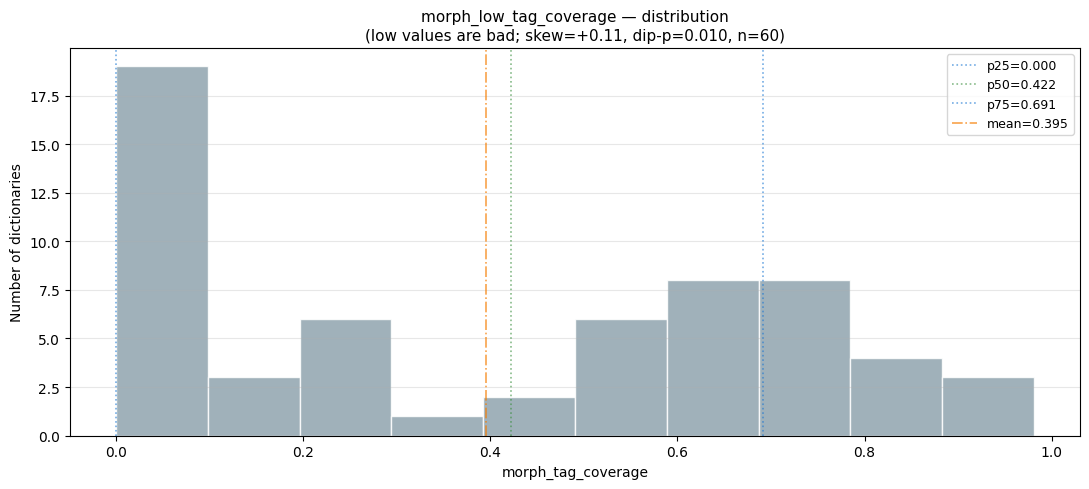


Per-dict ranked table (worst first):
  Top 15 worst:
rank dict_id  morph_tag_coverage  prep_rows  billex_rows  morph_rows  parcor_rows
   1       1                 0.0       3986           16           6         2914
   2       3                 0.0        833           19           1          125
   3       9                 0.0       2240           23           8         1049
   4      17                 0.0       2160            7           4         1673
   5      29                 0.0       1979            1           2         1588
   6      33                 0.0       2899           30          27         1855
   7      84                 0.0       1001            5           2          264
   8      94                 0.0        957           27           5          163
   9      70                 0.0        354          159           3           48
  10      85                 0.0       1239           26           1          532
  11      56                 0.0       3116 

In [31]:
explore_rule(
    rule_name="morph_low_tag_coverage",
    metric_col="morph_tag_coverage",
    direction="low",
)

## 6. `morph_too_few_rows`

**Metric:** `morph_rows`
**Direction:** low (low values are bad)
**Sort order in per-dict list:** ascending (worst dicts shown first)

=== morph_too_few_rows ===

Metric: morph_rows    Direction: low (low=bad)
Coverage: 68 valid values, 0 N/A (0.0% missing)

Summary statistics:
  min: 0.0000    max: 4621.0000
  mean: 591.8382    median: 115.0000    std: 976.6229
  skewness: +2.193    dip-test p-value: 0.9667
  shape hint: STRONGLY SKEWED (right tail)

Percentiles:
  p1=0.0000  p5=0.0000  p10=0.0000  p25=3.7500
  p50=115.0000  p75=728.0000  p90=2217.0000  p95=2670.3500  p99=3982.4900

What-if threshold table:
  threshold | flag count | flag rate | type
  ---------|-----------|-----------|-----------
  p5         |    0.0000 |      0 ( 0.0%) | quantile
  p10        |    0.0000 |      0 ( 0.0%) | quantile
  p25        |    3.7500 |     17 (25.0%) | quantile
  p50        |  115.0000 |     34 (50.0%) | quantile
  p75        |  728.0000 |     50 (73.5%) | quantile
  p90        | 2217.0000 |     61 (89.7%) | quantile
  p95        | 2670.3500 |     64 (94.1%) | quantile
  mean       |  591.8382 |     47 (69.1%) | landmark
  m

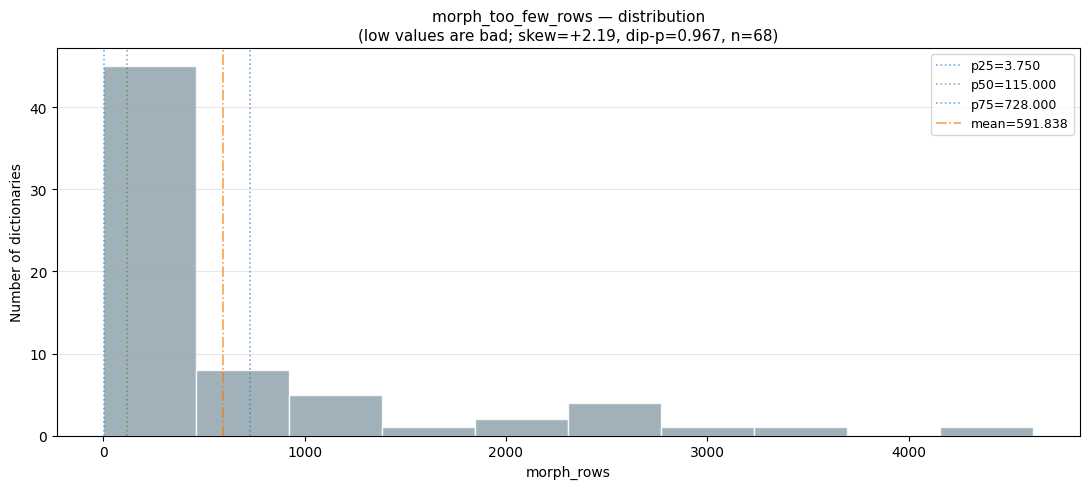


Per-dict ranked table (worst first):
  Top 15 worst:
 rank dict_id  morph_rows  prep_rows  billex_rows  morph_rows  parcor_rows
    1      31           0       1371            1           0          566
    2      32           0       3345            5           0         1261
    3      22           0        365            5           0           88
    4      20           0       2109            0           0         1719
    5      78           0       1195            2           0          311
    6      52           0       2679            5           0         2111
    7      48           0        233            1           0          193
    8      44           0       2001            3           0          687
    9       3           1        833           19           1          125
   10      85           1       1239           26           1          532
   11      56           1       3116           13           1         2347
   12      37           2        361          

In [32]:
explore_rule(
    rule_name="morph_too_few_rows",
    metric_col="morph_rows",
    direction="low",
)

## 7. `billex_high_multiword_ind`

**Metric:** `billex_multiword_ind_rate`
**Direction:** high (high values are bad)
**Sort order in per-dict list:** descending (worst dicts shown first)

=== billex_high_multiword_ind ===

Metric: billex_multiword_ind_rate    Direction: high (high=bad)
Coverage: 67 valid values, 1 N/A (1.5% missing)

Summary statistics:
  min: 0.0000    max: 1.0000
  mean: 0.3865    median: 0.2211    std: 0.3194
  skewness: +0.812    dip-test p-value: 0.3759
  shape hint: MILDLY SKEWED (right tail)

Percentiles:
  p1=0.0187  p5=0.0564  p10=0.0886  p25=0.1401
  p50=0.2211  p75=0.6667  p90=0.9211  p95=1.0000  p99=1.0000

What-if threshold table:
  threshold | flag count | flag rate | type
  ---------|-----------|-----------|-----------
  p5         |    0.0564 |     63 (94.0%) | quantile
  p10        |    0.0886 |     60 (89.6%) | quantile
  p25        |    0.1401 |     50 (74.6%) | quantile
  p50        |    0.2211 |     33 (49.3%) | quantile
  p75        |    0.6667 |     15 (22.4%) | quantile
  p90        |    0.9211 |      7 (10.4%) | quantile
  p95        |    1.0000 |      0 ( 0.0%) | quantile
  mean       |    0.3865 |     25 (37.3%) | landmark
  m

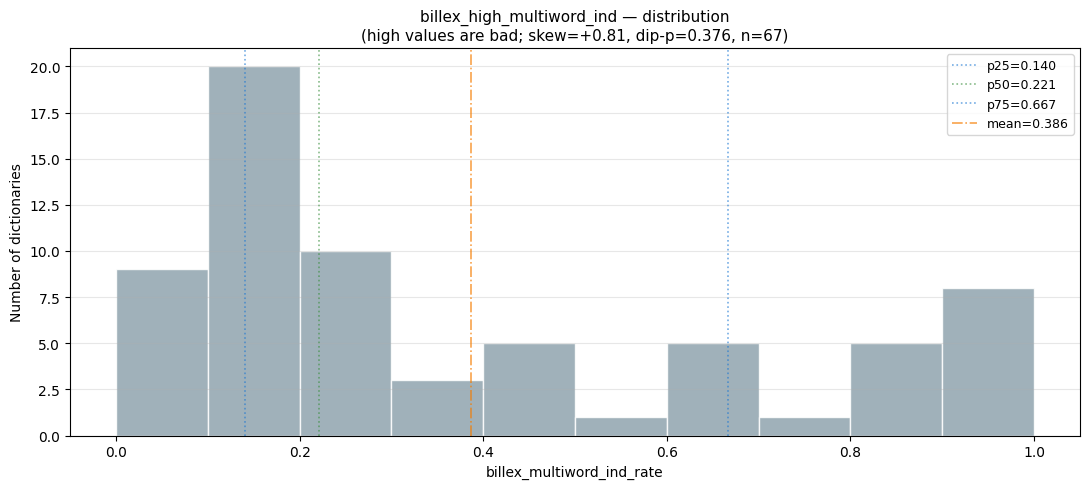


Per-dict ranked table (worst first):
  Top 15 worst:
rank dict_id  billex_multiword_ind_rate  prep_rows  billex_rows  morph_rows  parcor_rows
   1      29                     1.0000       1979            1           2         1588
   2      17                     1.0000       2160            7           4         1673
   3      22                     1.0000        365            5           0           88
   4      66                     1.0000       1657            2           6         1003
   5      78                     1.0000       1195            2           0          311
   6      48                     1.0000        233            1           0          193
   7      60                     0.9333       1643          105           7          942
   8       9                     0.9130       2240           23           8         1049
   9       3                     0.8947        833           19           1          125
  10      62                     0.8913       8739      

In [33]:
explore_rule(
    rule_name="billex_high_multiword_ind",
    metric_col="billex_multiword_ind_rate",
    direction="high",
)

## 8. `billex_too_few_rows`

**Metric:** `billex_rows`
**Direction:** low (low values are bad)
**Sort order in per-dict list:** ascending (worst dicts shown first)

=== billex_too_few_rows ===

Metric: billex_rows    Direction: low (low=bad)
Coverage: 68 valid values, 0 N/A (0.0% missing)

Summary statistics:
  min: 0.0000    max: 10077.0000
  mean: 1584.2941    median: 370.5000    std: 2489.5444
  skewness: +2.019    dip-test p-value: 0.9906
  shape hint: STRONGLY SKEWED (right tail)

Percentiles:
  p1=0.6700  p5=1.3500  p10=3.0000  p25=22.0000
  p50=370.5000  p75=1899.5000  p90=5485.0000  p95=7513.8500  p99=9943.0000

What-if threshold table:
  threshold | flag count | flag rate | type
  ---------|-----------|-----------|-----------
  p5         |    1.3500 |      4 ( 5.9%) | quantile
  p10        |    3.0000 |      6 ( 8.8%) | quantile
  p25        |   22.0000 |     17 (25.0%) | quantile
  p50        |  370.5000 |     34 (50.0%) | quantile
  p75        | 1899.5000 |     51 (75.0%) | quantile
  p90        | 5485.0000 |     61 (89.7%) | quantile
  p95        | 7513.8500 |     64 (94.1%) | quantile
  mean       | 1584.2941 |     49 (72.1%) | landm

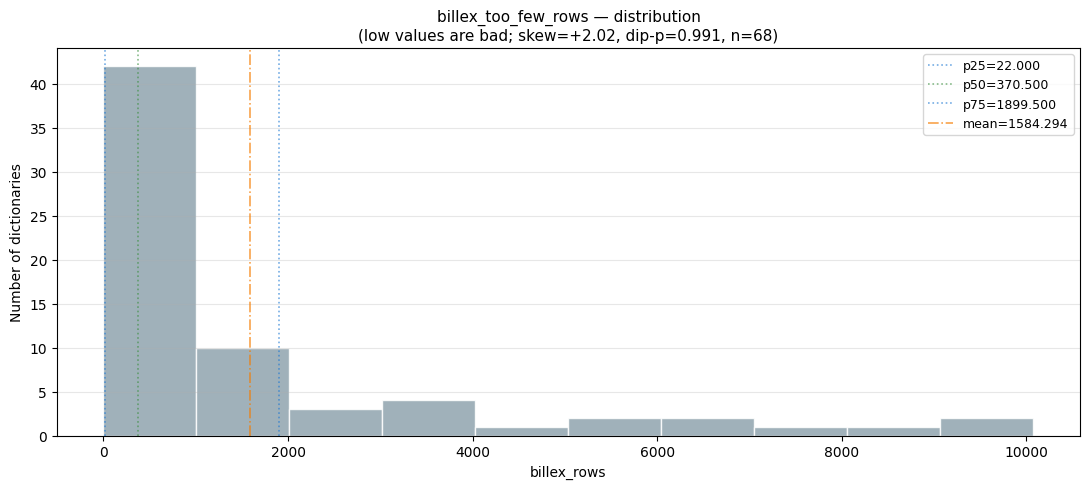


Per-dict ranked table (worst first):
  Top 15 worst:
 rank dict_id  billex_rows  prep_rows  billex_rows  morph_rows  parcor_rows
    1      20            0       2109            0           0         1719
    2      31            1       1371            1           0          566
    3      29            1       1979            1           2         1588
    4      48            1        233            1           0          193
    5      66            2       1657            2           6         1003
    6      78            2       1195            2           0          311
    7      44            3       2001            3           0          687
    8      61            3       2793            3           2         1090
    9      32            5       3345            5           0         1261
   10      52            5       2679            5           0         2111
   11      84            5       1001            5           2          264
   12      22            5        

In [34]:
explore_rule(
    rule_name="billex_too_few_rows",
    metric_col="billex_rows",
    direction="low",
)

## 9. `billex_high_null_rate`

**Metric:** `billex_null_rate`
**Direction:** high (high values are bad)
**Sort order in per-dict list:** descending (worst dicts shown first)

=== billex_high_null_rate ===

Metric: billex_null_rate    Direction: high (high=bad)
Coverage: 67 valid values, 1 N/A (1.5% missing)

Summary statistics:
  min: 0.0000    max: 0.1111
  mean: 0.0029    median: 0.0000    std: 0.0151
  skewness: +6.348    dip-test p-value: 1.0000
  shape hint: STRONGLY SKEWED (right tail)

Percentiles:
  p1=0.0000  p5=0.0000  p10=0.0000  p25=0.0000
  p50=0.0000  p75=0.0000  p90=0.0015  p95=0.0050  p99=0.0766

What-if threshold table:
  threshold | flag count | flag rate | type
  ---------|-----------|-----------|-----------
  p5         |    0.0000 |     14 (20.9%) | quantile
  p10        |    0.0000 |     14 (20.9%) | quantile
  p25        |    0.0000 |     14 (20.9%) | quantile
  p50        |    0.0000 |     14 (20.9%) | quantile
  p75        |    0.0000 |     14 (20.9%) | quantile
  p90        |    0.0015 |      7 (10.4%) | quantile
  p95        |    0.0050 |      3 ( 4.5%) | quantile
  mean       |    0.0029 |      5 ( 7.5%) | landmark
  mean − 1σ  |

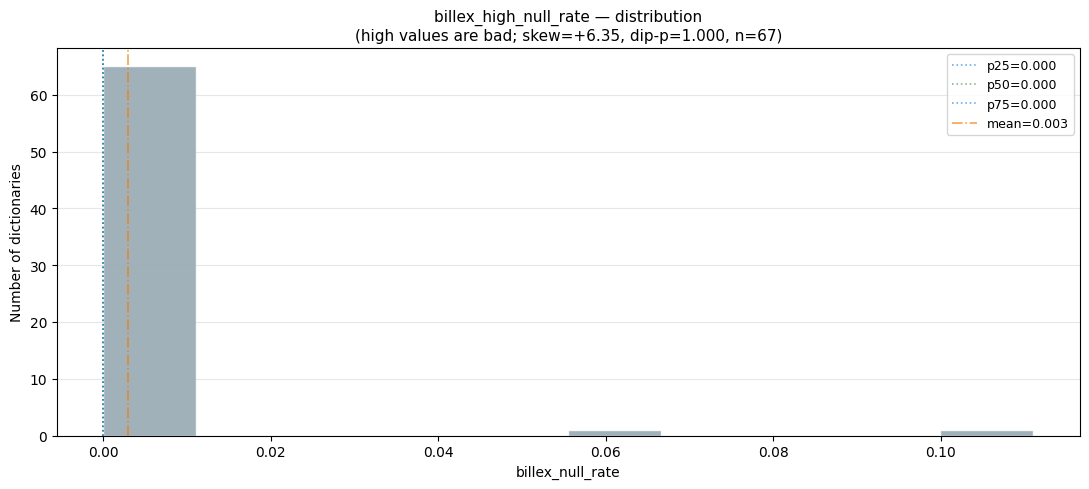


Per-dict ranked table (worst first):
  Top 15 worst:
rank dict_id  billex_null_rate  prep_rows  billex_rows  morph_rows  parcor_rows
   1      57            0.1111       2620            9           3         1529
   2      58            0.0588       5237           34           9         1532
   3      67            0.0062       3135          162          65          511
   4      15            0.0050       1495          401         155          711
   5      11            0.0050       2298          399         205          609
   6      50            0.0024       1620          410         252          679
   7      68            0.0016       7546         6936        2343         2044
   8      28            0.0015       1081          658         183          547
   9      79            0.0013       1877          754         331          783
  10      36            0.0007       2788         1434         626         1258
  11      34            0.0003      11207         5730        2322

In [35]:
explore_rule(
    rule_name="billex_high_null_rate",
    metric_col="billex_null_rate",
    direction="high",
)

## 10. `billex_low_retention`

**Metric:** `billex_retention`
**Direction:** low (low values are bad)
**Sort order in per-dict list:** ascending (worst dicts shown first)

=== billex_low_retention ===

Metric: billex_retention    Direction: low (low=bad)
Coverage: 68 valid values, 0 N/A (0.0% missing)

Summary statistics:
  min: 0.0000    max: 0.9783
  mean: 0.3215    median: 0.2671    std: 0.3006
  skewness: +0.383    dip-test p-value: 0.0354
  shape hint: BIMODAL (clear separation between two populations)

Percentiles:
  p1=0.0003  p5=0.0011  p10=0.0016  p25=0.0103
  p50=0.2671  p75=0.5945  p90=0.7008  p95=0.8159  p99=0.9451

What-if threshold table:
  threshold | flag count | flag rate | type
  ---------|-----------|-----------|-----------
  p5         |    0.0011 |      4 ( 5.9%) | quantile
  p10        |    0.0016 |      7 (10.3%) | quantile
  p25        |    0.0103 |     16 (23.5%) | quantile
  p50        |    0.2671 |     34 (50.0%) | quantile
  p75        |    0.5945 |     51 (75.0%) | quantile
  p90        |    0.7008 |     61 (89.7%) | quantile
  p95        |    0.8159 |     64 (94.1%) | quantile
  mean       |    0.3215 |     35 (51.5%) | land

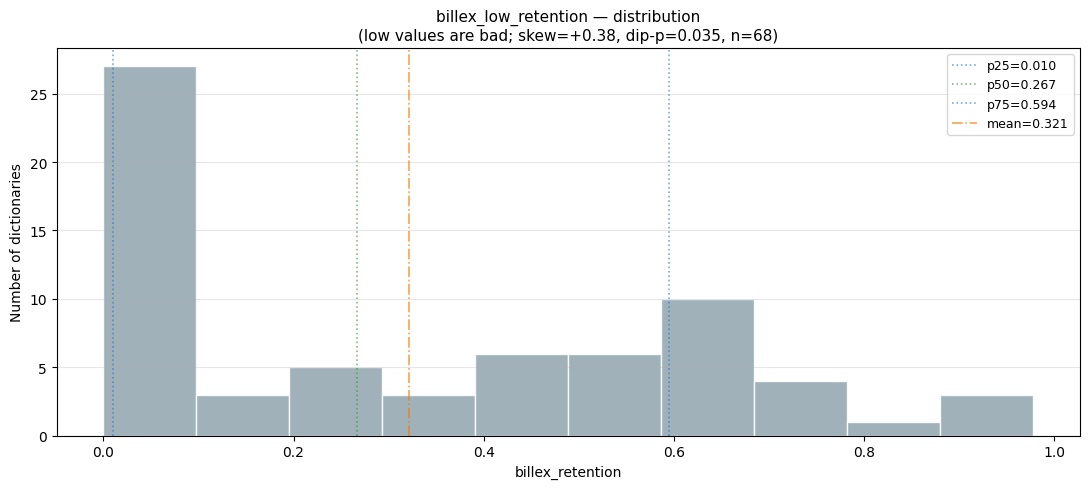


Per-dict ranked table (worst first):
  Top 15 worst:
 rank dict_id  billex_retention  prep_rows  billex_rows  morph_rows  parcor_rows
    1      20            0.0000       2109            0           0         1719
    2      29            0.0005       1979            1           2         1588
    3      31            0.0007       1371            1           0          566
    4      61            0.0011       2793            3           2         1090
    5      66            0.0012       1657            2           6         1003
    6      44            0.0015       2001            3           0          687
    7      32            0.0015       3345            5           0         1261
    8      78            0.0017       1195            2           0          311
    9      52            0.0019       2679            5           0         2111
   10      17            0.0032       2160            7           4         1673
   11      57            0.0034       2620            9

In [36]:
explore_rule(
    rule_name="billex_low_retention",
    metric_col="billex_retention",
    direction="low",
)

## 11. `parcor_high_placeholders`

**Metric:** `parcor_placeholder_rate`
**Direction:** high (high values are bad)
**Sort order in per-dict list:** descending (worst dicts shown first)

=== parcor_high_placeholders ===

Metric: parcor_placeholder_rate    Direction: high (high=bad)
Coverage: 68 valid values, 0 N/A (0.0% missing)

Summary statistics:
  min: 0.0006    max: 0.7500
  mean: 0.3603    median: 0.3778    std: 0.2019
  skewness: -0.220    dip-test p-value: 0.1183
  shape hint: APPROXIMATELY SYMMETRIC

Percentiles:
  p1=0.0008  p5=0.0035  p10=0.0216  p25=0.2319
  p50=0.3778  p75=0.5145  p90=0.6126  p95=0.6599  p99=0.7448

What-if threshold table:
  threshold | flag count | flag rate | type
  ---------|-----------|-----------|-----------
  p5         |    0.0035 |     64 (94.1%) | quantile
  p10        |    0.0216 |     61 (89.7%) | quantile
  p25        |    0.2319 |     51 (75.0%) | quantile
  p50        |    0.3778 |     34 (50.0%) | quantile
  p75        |    0.5145 |     17 (25.0%) | quantile
  p90        |    0.6126 |      7 (10.3%) | quantile
  p95        |    0.6599 |      4 ( 5.9%) | quantile
  mean       |    0.3603 |     37 (54.4%) | landmark
  mean − 

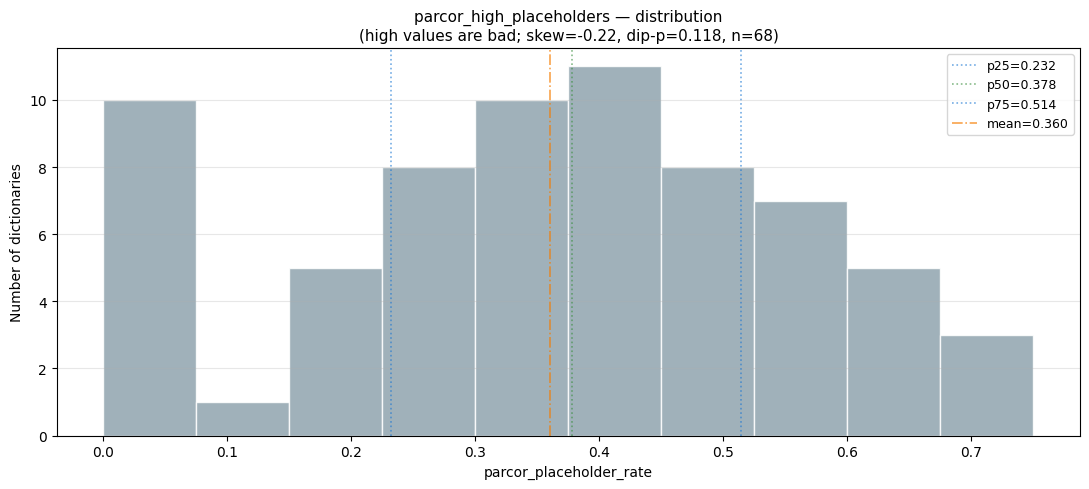


Per-dict ranked table (worst first):
  Top 15 worst:
 rank dict_id  parcor_placeholder_rate  prep_rows  billex_rows  morph_rows  parcor_rows
    1      70                   0.7500        354          159           3           48
    2      37                   0.7423        361           96           2          260
    3      20                   0.7208       2109            0           0         1719
    4      10                   0.6638       5260         3800        1125         2942
    5       4                   0.6527       3212         1894         728         2658
    6      77                   0.6194       1780         1284         278         1353
    7      21                   0.6166       2990         1485         482         2019
    8      63                   0.6109       1084          256          53          825
    9      55                   0.5970       2668         1508         422         1829
   10      29                   0.5913       1979            1    

In [37]:
explore_rule(
    rule_name="parcor_high_placeholders",
    metric_col="parcor_placeholder_rate",
    direction="high",
)

## 12. `parcor_too_few_rows`

**Metric:** `parcor_rows`
**Direction:** low (low values are bad)
**Sort order in per-dict list:** ascending (worst dicts shown first)

=== parcor_too_few_rows ===

Metric: parcor_rows    Direction: low (low=bad)
Coverage: 68 valid values, 0 N/A (0.0% missing)

Summary statistics:
  min: 48.0000    max: 8484.0000
  mean: 1711.7353    median: 1259.5000    std: 1526.7523
  skewness: +1.863    dip-test p-value: 0.9844
  shape hint: STRONGLY SKEWED (right tail)

Percentiles:
  p1=74.8000  p5=173.5000  p10=262.8000  p25=661.5000
  p50=1259.5000  p75=2293.7500  p90=3689.6000  p95=4637.7500  p99=6537.6500

What-if threshold table:
  threshold | flag count | flag rate | type
  ---------|-----------|-----------|-----------
  p5         |  173.5000 |      4 ( 5.9%) | quantile
  p10        |  262.8000 |      7 (10.3%) | quantile
  p25        |  661.5000 |     17 (25.0%) | quantile
  p50        | 1259.5000 |     34 (50.0%) | quantile
  p75        | 2293.7500 |     51 (75.0%) | quantile
  p90        | 3689.6000 |     61 (89.7%) | quantile
  p95        | 4637.7500 |     64 (94.1%) | quantile
  mean       | 1711.7353 |     40 (58.8%)

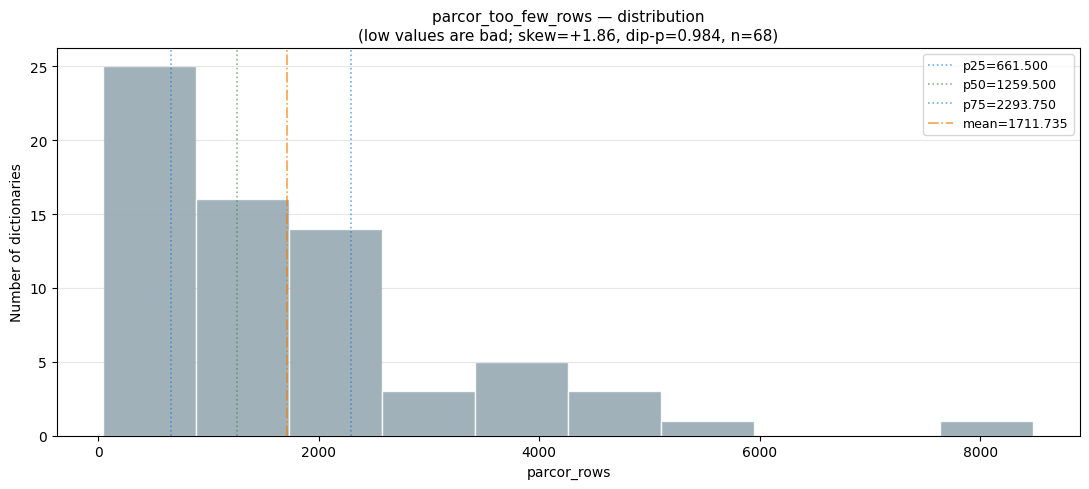


Per-dict ranked table (worst first):
  Top 15 worst:
 rank dict_id  parcor_rows  prep_rows  billex_rows  morph_rows  parcor_rows
    1      70           48        354          159           3           48
    2      22           88        365            5           0           88
    3       3          125        833           19           1          125
    4      94          163        957           27           5          163
    5      48          193        233            1           0          193
    6      25          195        440          168         143          195
    7      37          260        361           96           2          260
    8      84          264       1001            5           2          264
    9      78          311       1195            2           0          311
   10       8          413       2281          342         124          413
   11      67          511       3135          162          65          511
   12      85          532       1

In [38]:
explore_rule(
    rule_name="parcor_too_few_rows",
    metric_col="parcor_rows",
    direction="low",
)

## 13. `parcor_high_null_rate`

**Metric:** `parcor_null_rate`
**Direction:** high (high values are bad)
**Sort order in per-dict list:** descending (worst dicts shown first)

=== parcor_high_null_rate ===

Metric: parcor_null_rate    Direction: high (high=bad)
Coverage: 68 valid values, 0 N/A (0.0% missing)

Summary statistics:
  min: 0.0000    max: 0.1790
  mean: 0.0388    median: 0.0265    std: 0.0418
  skewness: +1.716    dip-test p-value: 0.6108
  shape hint: STRONGLY SKEWED (right tail)

Percentiles:
  p1=0.0000  p5=0.0010  p10=0.0032  p25=0.0108
  p50=0.0265  p75=0.0500  p90=0.1121  p95=0.1267  p99=0.1759

What-if threshold table:
  threshold | flag count | flag rate | type
  ---------|-----------|-----------|-----------
  p5         |    0.0010 |     64 (94.1%) | quantile
  p10        |    0.0032 |     61 (89.7%) | quantile
  p25        |    0.0108 |     51 (75.0%) | quantile
  p50        |    0.0265 |     34 (50.0%) | quantile
  p75        |    0.0500 |     17 (25.0%) | quantile
  p90        |    0.1121 |      7 (10.3%) | quantile
  p95        |    0.1267 |      4 ( 5.9%) | quantile
  mean       |    0.0388 |     24 (35.3%) | landmark
  mean − 1σ  |

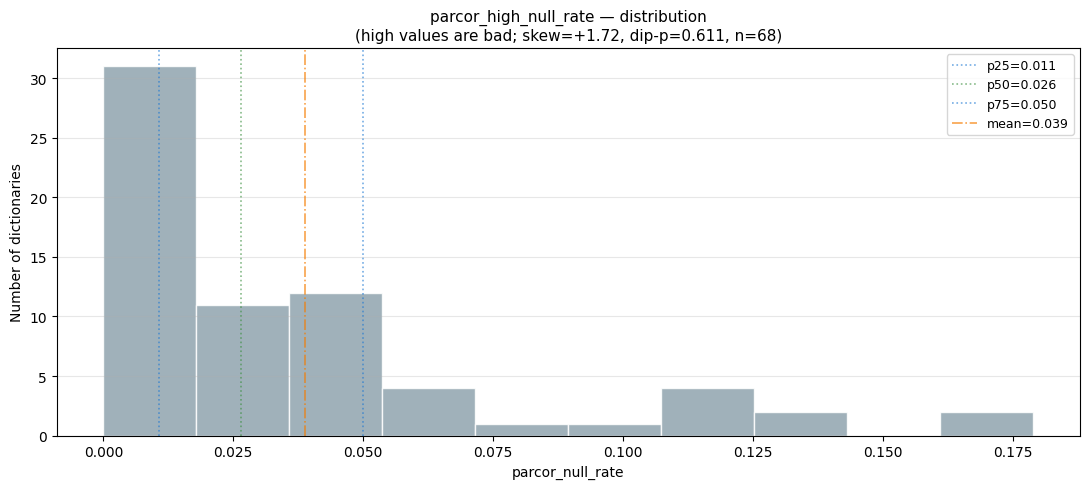


Per-dict ranked table (worst first):
  Top 15 worst:
 rank dict_id  parcor_null_rate  prep_rows  billex_rows  morph_rows  parcor_rows
    1      11            0.1790       2298          399         205          609
    2       8            0.1743       2281          342         124          413
    3      78            0.1383       1195            2           0          311
    4      58            0.1286       5237           34           9         1532
    5      67            0.1233       3135          162          65          511
    6      62            0.1176       8739           92          63         3632
    7      26            0.1168       4735         3137        1014          591
    8      34            0.1101      11207         5730        2322         4407
    9      31            0.1025       1371            1           0          566
   10      45            0.0789       3661         2377        1039         2332
   11      15            0.0647       1495          401

In [39]:
explore_rule(
    rule_name="parcor_high_null_rate",
    metric_col="parcor_null_rate",
    direction="high",
)

## 14. `parcor_high_short_rows`

**Metric:** `parcor_short_rate`
**Direction:** high (high values are bad)
**Sort order in per-dict list:** descending (worst dicts shown first)

=== parcor_high_short_rows ===

Metric: parcor_short_rate    Direction: high (high=bad)
Coverage: 68 valid values, 0 N/A (0.0% missing)

Summary statistics:
  min: 0.0625    max: 0.7966
  mean: 0.3103    median: 0.2623    std: 0.1807
  skewness: +0.742    dip-test p-value: 0.9772
  shape hint: MILDLY SKEWED (right tail)

Percentiles:
  p1=0.0708  p5=0.0886  p10=0.1108  p25=0.1696
  p50=0.2623  p75=0.4327  p90=0.5853  p95=0.6507  p99=0.7252

What-if threshold table:
  threshold | flag count | flag rate | type
  ---------|-----------|-----------|-----------
  p5         |    0.0886 |     64 (94.1%) | quantile
  p10        |    0.1108 |     61 (89.7%) | quantile
  p25        |    0.1696 |     51 (75.0%) | quantile
  p50        |    0.2623 |     34 (50.0%) | quantile
  p75        |    0.4327 |     17 (25.0%) | quantile
  p90        |    0.5853 |      7 (10.3%) | quantile
  p95        |    0.6507 |      4 ( 5.9%) | quantile
  mean       |    0.3103 |     29 (42.6%) | landmark
  mean − 1σ  |

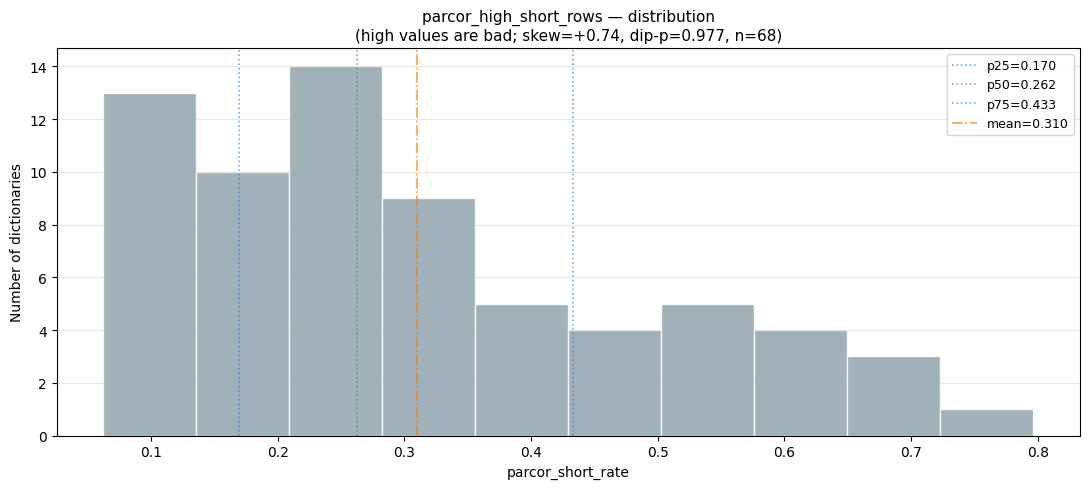


Per-dict ranked table (worst first):
  Top 15 worst:
 rank dict_id  parcor_short_rate  prep_rows  billex_rows  morph_rows  parcor_rows
    1       8             0.7966       2281          342         124          413
    2       5             0.6901       3853         2395         820          697
    3      18             0.6561      14876         9877        2684         2341
    4      26             0.6531       4735         3137        1014          591
    5      78             0.6463       1195            2           0          311
    6      58             0.6044       5237           34           9         1532
    7      84             0.5985       1001            5           2          264
    8      11             0.5796       2298          399         205          609
    9      62             0.5694       8739           92          63         3632
   10      34             0.5571      11207         5730        2322         4407
   11      50             0.5567       1620 

In [40]:
explore_rule(
    rule_name="parcor_high_short_rows",
    metric_col="parcor_short_rate",
    direction="high",
)

## 15. Combined per-rule distributions CSV

A single wide-format CSV with each dict's value for every rule. Use this
for cross-rule analysis (e.g., "do dicts with low tag_coverage also have
low retention?").

In [41]:
combined_cols = ["dict_id", "prep_rows", "direction"]
metric_cols = ['morph_tag_coverage', 'morph_rows', 'billex_multiword_ind_rate', 'billex_rows', 'billex_null_rate', 'billex_retention', 'parcor_placeholder_rate', 'parcor_rows', 'parcor_null_rate', 'parcor_short_rate']
existing = [c for c in metric_cols if c in metrics_df.columns]
combined = metrics_df[combined_cols + existing].copy()
combined.to_csv(DST_DIR / "_per_rule_distributions.csv", index=False)
print(f"Wrote: {DST_DIR / '_per_rule_distributions.csv'}  ({len(combined)} dicts × {len(combined.columns)} cols)")
combined.head(10)

Wrote: ..\csvAnalysis\distribution_exploration\_per_rule_distributions.csv  (68 dicts × 13 cols)


,dict_id,prep_rows,direction,morph_tag_coverage,morph_rows,billex_multiword_ind_rate,billex_rows,billex_null_rate,billex_retention,parcor_placeholder_rate,parcor_rows,parcor_null_rate,parcor_short_rate
0,1,3986,0,0.0000,6,0.6875,16,0.000,0.0040,0.0075,2914,0.0075,0.3236
1,2,4752,0,0.2500,12,0.4342,76,0.000,0.0160,0.3410,2047,0.0513,0.3845
2,3,833,0,0.0000,1,0.8947,19,0.000,0.0228,0.5040,125,0.0400,0.2800
3,4,3212,1,0.5412,728,0.1193,1894,0.000,0.5897,0.6527,2658,0.0011,0.1144
4,5,3853,1,0.6841,820,0.1846,2395,0.000,0.6216,0.0014,697,0.0287,0.6901
5,8,2281,1,0.2016,124,0.2368,342,0.000,0.1499,0.1162,413,0.1743,0.7966
6,9,2240,0,0.0000,8,0.9130,23,0.000,0.0103,0.3317,1049,0.0439,0.3880
7,10,5260,1,0.8542,1125,0.0884,3800,0.000,0.7224,0.6638,2942,0.0034,0.0867
8,11,2298,0,0.1366,205,0.3634,399,0.005,0.1736,0.3875,609,0.1790,0.5796
9,12,9400,1,0.6726,2645,0.2211,6192,0.000,0.6587,0.3838,4810,0.0362,0.4534


## 16. Decision template

Empty template for you to fill in your chosen thresholds. After making
decisions per rule, fill in the `chosen_threshold` column. The next sanity
check iteration can read this CSV directly.

In [42]:
template_rows = []
rules_meta = [('morph_low_tag_coverage', 'morph_tag_coverage', 'low'), ('morph_too_few_rows', 'morph_rows', 'low'), ('billex_high_multiword_ind', 'billex_multiword_ind_rate', 'high'), ('billex_too_few_rows', 'billex_rows', 'low'), ('billex_high_null_rate', 'billex_null_rate', 'high'), ('billex_low_retention', 'billex_retention', 'low'), ('parcor_high_placeholders', 'parcor_placeholder_rate', 'high'), ('parcor_too_few_rows', 'parcor_rows', 'low'), ('parcor_high_null_rate', 'parcor_null_rate', 'high'), ('parcor_high_short_rows', 'parcor_short_rate', 'high')]
for rule_name, metric_col, direction in rules_meta:
    template_rows.append({
        "rule_name":         rule_name,
        "metric_column":     metric_col,
        "direction":         direction,
        "chosen_threshold":  "",
        "rationale":         "",
        "decided_on":        "",
    })
template_df = pd.DataFrame(template_rows)
template_df.to_csv(DST_DIR / "_my_thresholds.csv", index=False)
print(f"Wrote decision template: {DST_DIR / '_my_thresholds.csv'}")
print(f"\nFill in the 'chosen_threshold' column for each rule, then save.")
template_df

Wrote decision template: ..\csvAnalysis\distribution_exploration\_my_thresholds.csv

Fill in the 'chosen_threshold' column for each rule, then save.


,rule_name,metric_column,direction,chosen_threshold,rationale,decided_on
0,morph_low_tag_coverage,morph_tag_coverage,low,,,
1,morph_too_few_rows,morph_rows,low,,,
2,billex_high_multiword_ind,billex_multiword_ind_rate,high,,,
3,billex_too_few_rows,billex_rows,low,,,
4,billex_high_null_rate,billex_null_rate,high,,,
5,billex_low_retention,billex_retention,low,,,
6,parcor_high_placeholders,parcor_placeholder_rate,high,,,
7,parcor_too_few_rows,parcor_rows,low,,,
8,parcor_high_null_rate,parcor_null_rate,high,,,
9,parcor_high_short_rows,parcor_short_rate,high,,,


## How to use this notebook

For each rule:

1. **Read the diagnostics** at the top — does the data look bimodal,
   skewed, symmetric? This shapes your intuition.
2. **Look at the what-if table** — do any of the candidate thresholds
   produce a flag count that matches your intuition for "how many should
   be bad"?
3. **Look at the histogram** — where does the distribution have natural
   gaps or breaks?
4. **Open the per-rule CSV** — scan the top of the ranked list. Where
   does the metric value transition from "this is clearly bad" to
   "this is acceptable"?
5. **Decide your threshold and write it in `_my_thresholds.csv`** along
   with a one-sentence rationale.

The rationale matters because it's what you'll defend to your advisor.
"At p25 the threshold flags 17 dicts which roughly matches the
catastrophic failure count" is defensible. "I picked 0.3 because it
felt right" is not.

For some rules the right threshold may be 0 (only literally-empty cases
are bad). For others it may be high (most dicts are bad and only a few
clean ones pass). The point is to look at each rule's own evidence and
decide based on that, not on a universal recipe.